In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import scanpy as sc
import os
from dotenv import load_dotenv; load_dotenv()
import numpy as np
import matplotlib.pyplot as plt

from utils import preprocessing


BASE_PATH = os.getenv("BASE_PATH_FOR_SAVING")

FINAL_ADATA_PATH = f"/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags.h5ad"


In [2]:
adata_list = []
sample_info = []  # Track metadata

for state in ["healthy", "diseased"]:

    state_dir = f"{BASE_PATH}/{state}"

    for sample in os.listdir(state_dir):
        
        print(f"Loading: {state} | {sample}")

        h5ad_path = f"{state_dir}/{sample}/adata/all_lib_adata_zoned.h5ad"

        # Skip if file doesn't exist
        if not os.path.isfile(h5ad_path):
            print(f"[SKIP] Missing file: {h5ad_path}")
            continue

        adata_tmp = sc.read_h5ad(f"{BASE_PATH}/{state}/{sample}/adata/all_lib_adata_zoned.h5ad")#, backed="r")

        # save raw counts in X
        adata_tmp.X = adata_tmp.layers["counts"].copy()

        # Add metadata to track origin
        adata_tmp.obs['sample'] = sample
        adata_tmp.obs['state'] = state
        adata_tmp.obs['sample_state'] = f"{state}_{sample}"

        # make cells id unique      
        adata_tmp.obs_names = adata_tmp.obs["sample_state"] + "_" + adata_tmp.obs_names.astype(str)

        print(adata_tmp)
        
        adata_list.append(adata_tmp)
        sample_info.append(f"{state}_{sample}")


# Step 2: Check gene overlap
gene_sets    = [set(a.var_names) for a in adata_list]
common_genes = set.intersection(*gene_sets)
all_genes    = set.union(*gene_sets)
print(f"\n[GENES] Common: {len(common_genes)} | Total: {len(all_genes)} | Only-in-some: {len(all_genes) - len(common_genes)}")

# Save var info from any adata BEFORE concat (they all have the same genes)
#    #sc.concat silently drops .var columns when doing join='inner'
# we cna take whatever ada we want, we are thne makeing inner join
var_info = adata_list[0].var[["gene_symbol"]].copy()  # adjust column name if different


# Use intersection 
adata_combined_intersection = sc.concat(
    #sc.concat silently drops .var columns when doing join='inner'
    adata_list,
    join='inner',  # Keep only common genes
    label=None, # NAME of the new column added to .obs
    keys=None, # VALUES put in that column, one per adata
    index_unique=None  # We already made names unique --<  # obs_names become: "BARCODE-KeysA", "BARCODE-KeysB"
)

# Restore var info for the common genes
adata_combined_intersection.var = var_info.loc[adata_combined_intersection.var_names]

print(f"Combined shape (intersection): {adata_combined_intersection.shape}")
print(f"  Cells: {adata_combined_intersection.n_obs}")
print(f"  Genes: {adata_combined_intersection.n_vars}")

del adata_list
print(adata_combined_intersection)

# ── SANITY CHECKS ─────────────────────────────────────────────────────────────
assert adata_combined_intersection.obs_names.is_unique,              "ERROR: obs_names are not unique!"
assert adata_combined_intersection.obs["state"].notna().all(),       "ERROR: missing state labels!"
assert adata_combined_intersection.obs["sample"].notna().all(),      "ERROR: missing sample labels!"

print(f"\n[DONE] {adata_combined_intersection.n_obs} cells x {adata_combined_intersection.n_vars} genes")
print(adata_combined_intersection.obs[["state", "sample", "sample_state"]].value_counts())


Loading: diseased | sample_01
AnnData object with n_obs × n_vars = 85189 × 32780
    obs: 'x', 'y', 'pct_intronic', 'is_cell', 'dbscan_clusters', 'dbscan_score', 'has_spatial', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Neighborhood_aggregate_probability', 'Class_name', 'Class_bootstrapping_probability', 'Class_aggregate_probability', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Subclass_aggregate_probability', 'Group_name', 'Group_bootstrapping_probability', 'Group_aggregate_probability', 'Cluster_label', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'my_hierarchy_all', 'library', 'library_name', 'leiden_1', 'leiden_2', 'leiden_3', 'leiden_4', 'leiden_scANVI', 'mapping_MSN_for_zoning', 'mapping_coupling_for_zoning', 'zone', 'zone_probability', 'mapping_coupling_for_zoning_4_zones', 'zo

In [3]:
adata_combined_intersection.write_h5ad(FINAL_ADATA_PATH)

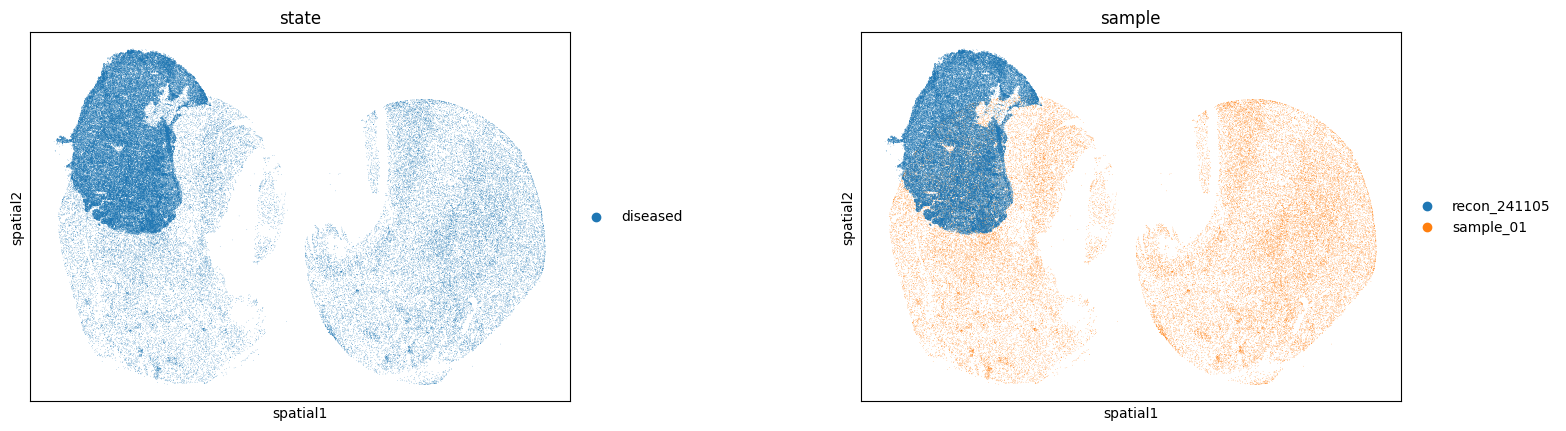

In [4]:
sc.pl.embedding(adata_combined_intersection, basis="spatial", color=["state", "sample"], wspace=0.4)